<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P6_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #6 :** *Operaciones aritméticas y lógicas*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. OPERACIONES ARITMETICAS**


***Instrucciones:*** Realiza las operaciones aritméticas a las imágenes médicas.

### **EJERCICIO 1.** ***Suma de imagenes.***

Para este ejercicio se utilizó la misma imagen de rayos X en dos versiones diferentes: una versión suavizada y otra con mayor contraste. El uso de ambas se justifica debido a que la imagen borrosa contribuye a la reducción del ruido al eliminar variaciones bruscas de intensidad, mientras que la imagen con mayor contraste permite resaltar las estructuras óseas y mejorar la definición de los bordes. Al realizar la suma se espera integrar la suavidad y el detalle de ambas, obteniendo una imagen más equilibrada que favorece la interpretación de las fracturas presentes.



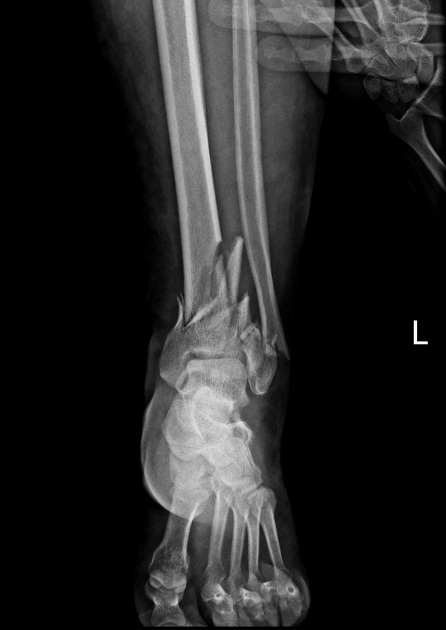

En la primera parte del código se importan las librerías **cv2**, **numpy** y **matplotlib.pyplot**, donde ***cv2*** permite el manejo de imágenes, ***numpy*** se utiliza para realizar operaciones matemáticas sobre matrices y ***matplotlib.pyplot*** se emplea para la visualización de resultados.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Posteriormente, se cargan las dos imágenes en escala de grises utilizando ***cv2.imread()*** con el parámetro ***cv2.IMREAD_GRAYSCALE***.

In [ ]:
img1 = cv2.imread("fracture.jpeg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("fracture.2.jpeg", cv2.IMREAD_GRAYSCALE)

Para asegurarnos que ambas imágenes tienen el mismo tamaño durante el procesamiento, se utiliza ***cv2.resize()*** para ajustarlas a una misma resolución. Esto es indispensable para poder realizar operaciones aritméticas entre píxeles.

In [ ]:
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

En la siguiente sección se aplica la suma ponderada mediante la función ***cv2.addWeighted()***, la cual combina ambas imágenes asignando un **peso específico** a cada una. Los parámetros **alpha**; que corresponde a la ***imagen no. 1***, y **beta**; que corresponde a la ***imagen no. 2***, controlan la proporción de cada imagen en el resultado final, permitiendo resaltar una sobre la otra.

In [ ]:
alpha = 0.6
beta = 0.4

suma_pond = cv2.addWeighted(img1, alpha, img2, beta, 0)

Posteriormente, se realiza la **suma promedio**, la cual consiste en sumar ambas imágenes y dividir el resultado entre dos. Esta operación se realiza de forma directa y  utiliza ***astype(np.uint8)*** para asegurar que los valores se mantengan dentro del rango válido de intensidades que es de **0 a 255**.

In [ ]:
suma_prom = (img1 + img2) / 2
suma_prom = suma_prom.astype(np.uint8)

Finalmente, los resultados se visualizan organizando las imágenes mediante **plt.subplot()** para facilitar la comparación entre las imágenes originales y las imágenes resultantes. Obteniendo el siguiente resultado.

La suma ponderada permitió combinar ambas imágenes controlando la contribución de cada una mediante los pesos establecidos. Como resultado, se obtuvo una **imagen más equilibrad**a, donde se redujo el ruido gracias a la versión suavizada, mientras que se conservaron los detalles estructurales provenientes de la imagen con mayor contraste. Esto **favorece la visualización de la estructura ósea** y permite **identificar con mayor claridad ambas fracturas**.


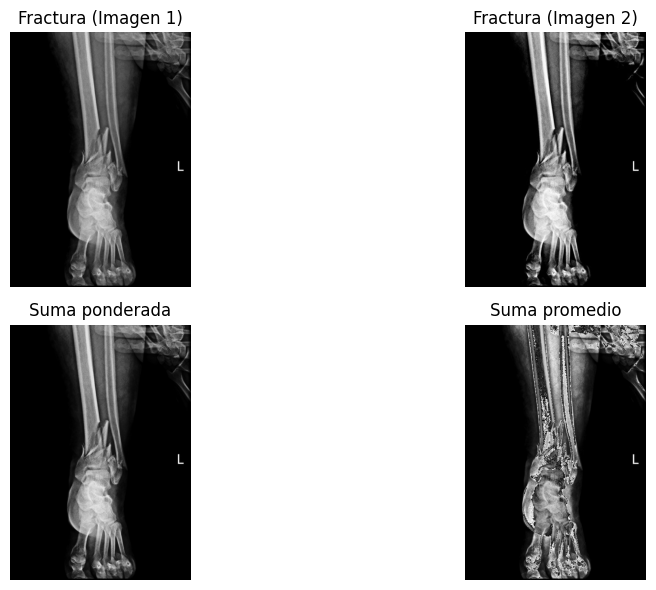

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img1, cmap="gray")
plt.title("Fractura (Imagen 1)")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img2, cmap="gray")
plt.title("Fractura (Imagen 2)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(suma_pond, cmap="gray")
plt.title("Suma ponderada")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(suma_prom, cmap="gray")
plt.title("Suma promedio")
plt.axis("off")

plt.tight_layout()
plt.show()

### **EJERCICIO 2.** ***Resta de imagenes.***

Para esta parte del análisis se utilizaron dos imágenes de resonancia magnética en plano sagital de la columna lumbar, correspondientes a las secuencias T1 y T2. El uso de estas dos secuencias se justifica debido a que cada una resalta diferentes propiedades de los tejidos: **la secuencia T1** permite una mejor visualización de la anatomía general y la estructura ósea, mientras que la **secuencia T2** destaca el contenido líquido, lo cual resulta útil para **evaluar los discos intervertebrales**.

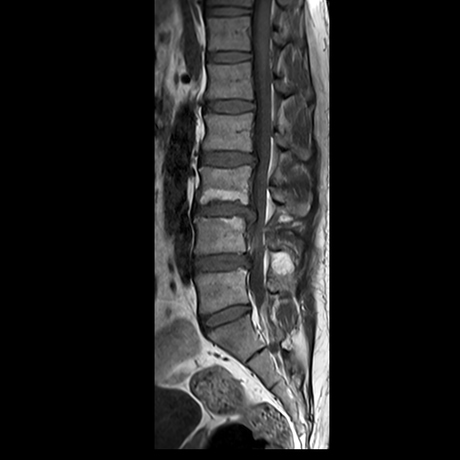 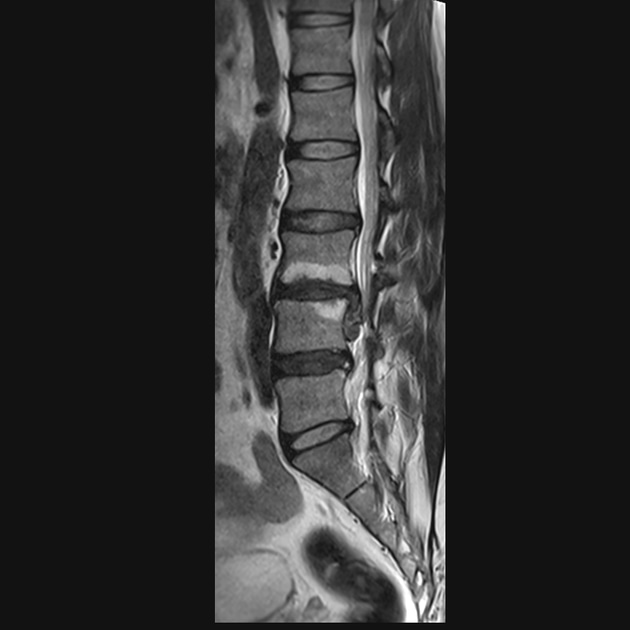

En la primera parte del código se importan las librerías **cv2**, **numpy** y **matplotlib.pyplot**, donde ***cv2*** permite el manejo de imágenes, ***numpy*** se utiliza para realizar operaciones matemáticas sobre matrices y ***matplotlib.pyplot*** se emplea para la visualización de resultados. Se cargan las dos imágenes en escala de grises utilizando ***cv2.imread()*** con el parámetro ***cv2.IMREAD_GRAYSCALE*** y para poder realizar las operaciones entre pixeles; nos aseguramos que ambas imágenes tienen el mismo tamaño con ***cv2.resize()***.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("sagital1.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("sagital2.jpg", cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

Se realiza la resta directa entre ambas imágenes mediante una resta simple. Esta operación puede generar valores negativos, lo cual puede afectar al visualizar la imagen debido al rango con el cual trabajan las imágenes en escala de grises (0 a 255).

Para evitar este problema, se utiliza la ***función cv2.absdiff()***, la cual calcula la diferencia absoluta entre ambas imágenes. Esta función garantiza que **todos los valores sean positivos,** permitiendo una representación correcta de las diferencias entre las imágenes y **resaltando las zonas donde existen cambios de intensidad.**

In [ ]:
resta = img1 - img2
resta_abs = cv2.absdiff(img1, img2)

Finalmente, los resultados se visualizan organizando las imágenes mediante **plt.subplot()** para facilitar la comparación entre las imágenes originales y las imágenes resultantes. Obteniendo el siguiente resultado. La resta entre imágenes **T1** y **T2** permite evidenciar diferencias de contraste relacionadas con la composición del tejido, particularmente en estructuras como los discos intervertebrales. Aunque no es una técnica diagnóstica directa, sirve de apoyo para resaltar variaciones en el **contenido líquido**.

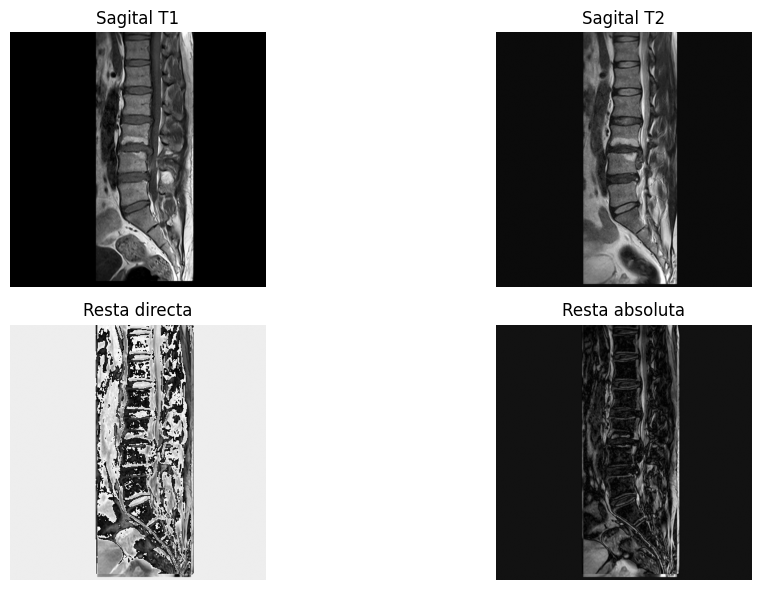

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img1, cmap="gray")
plt.title("Sagital T1")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img2, cmap="gray")
plt.title("Sagital T2")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(resta, cmap="gray")
plt.title("Resta directa")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(resta_abs, cmap="gray")
plt.title("Resta absoluta")
plt.axis("off")

plt.tight_layout()
plt.show()

### **EJERCICIO 3.** ***Multiplicación por un factor.***

Para este ejercicio se utilizaron las librerías necesarias para la lectura, procesamiento y visualización de imágenes en Python.
Se definieron tres factores de multiplicación: 1.5, 2 y 5. Estos valores permiten modificar el brillo de la imagen en diferentes niveles, donde un valor mayor incrementa significativamente la intensidad de los píxeles.

In [ ]:
img1= cv2.imread(r"medulloblastoma.jpg", cv2.IMREAD_GRAYSCALE)
img2= cv2.imread(r"fibromuscular.jpg", cv2.IMREAD_GRAYSCALE)
fact1=1.5
fact2=2
fact3=5

Posteriormente, se realizó la multiplicación de cada imagen por los factores definidos utilizando la función cv2.multiply(). Esta función multiplica cada valor de intensidad de los píxeles por un factor constante, lo que provoca un aumento directo en el brillo de la imagen. Este proceso se aplicó de manera independiente para cada factor y para ambas imágenes.


In [ ]:
img1_mult1=cv2.multiply(img1, np.array([fact1], dtype=np.float32))
img1_mult2=cv2.multiply(img1, np.array([fact2], dtype=np.float32))
img1_mult3=cv2.multiply(img1, np.array([fact3], dtype=np.float32))

img2_mult1=cv2.multiply(img2, np.array([fact1], dtype=np.float32))
img2_mult2=cv2.multiply(img2, np.array([fact2], dtype=np.float32))
img2_mult3=cv2.multiply(img2, np.array([fact3], dtype=np.float32))


Después, se realizó la conversión de las imágenes resultantes a formato uint8 mediante la función cv2.convertScaleAbs(). Esta función permite ajustar los valores de intensidad al rango válido de visualización (0 a 255), evitando desbordamientos o saturaciones incorrectas, lo cual es necesario después de realizar operaciones aritméticas sobre la imagen.


In [ ]:
img1_mul1=cv2.convertScaleAbs(img1_mult1)
img1_mul2=cv2.convertScaleAbs(img1_mult2)
img1_mul3=cv2.convertScaleAbs(img1_mult3)

img2_mul1=cv2.convertScaleAbs(img2_mult1)
img2_mul2=cv2.convertScaleAbs(img2_mult2)
img2_mul3=cv2.convertScaleAbs(img2_mult3)

Finalmente, se visualizaron las imágenes originales junto con las imágenes modificadas para cada factor. En los resultados se puede observar que conforme aumenta el factor de multiplicación, el brillo de la imagen se incrementa considerablemente. Sin embargo, valores muy altos, como el factor 5, provocan saturación en las zonas más claras, lo que puede ocasionar pérdida de información. Por otro lado, factores moderados permiten mejorar la visibilidad de ciertas estructuras sin afectar significativamente la calidad de la imagen.


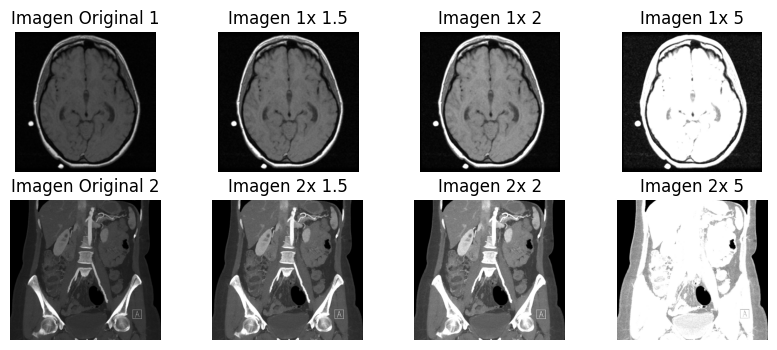

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(2,4,1)
plt.imshow(img1, cmap='gray')
plt.title("Imagen Original 1")
plt.axis("off")

plt.subplot(2,4,5)
plt.imshow(img2, cmap='gray')
plt.title("Imagen Original 2")
plt.axis("off")

plt.subplot(2,4,2)
plt.imshow(img1_mult1, cmap='gray')
plt.title(f"Imagen 1x {fact1}")
plt.axis("off")
plt.subplot(2,4,3)
plt.imshow(img1_mult2, cmap='gray')
plt.title(f"Imagen 1x {fact2}")
plt.axis("off")
plt.subplot(2,4,4)
plt.imshow(img1_mult3, cmap='gray')
plt.title(f"Imagen 1x {fact3}")
plt.axis("off")

plt.subplot(2,4,6)
plt.imshow(img2_mult1, cmap='gray')
plt.title(f"Imagen 2x {fact1}")
plt.axis("off")
plt.subplot(2,4,7)
plt.imshow(img2_mult2, cmap='gray')
plt.title(f"Imagen 2x {fact2}")
plt.axis("off")
plt.subplot(2,4,8)
plt.imshow(img2_mult3, cmap='gray')
plt.title(f"Imagen 2x {fact3}")
plt.axis("off")

plt.show()

### **EJERCICIO 4.** ***Multiplicacion elemento por elemento.***

Para este ejercicio se utilizaron las mismas imágenes médicas empleadas anteriormente, trabajando nuevamente en escala de grises para analizar los valores de intensidad de cada píxel.
Primero ajustamos el tamaño de ambas imágenes para que coincidieran en sus dimensiones. Esto se realizó mediante la función cv2.resize(), utilizando las dimensiones de la primera imagen como referencia. Esto es necesariol, ya que la multiplicación elemento por elemento requiere que ambas imágenes tengan el mismo número de filas y columnas.


In [ ]:
img2=cv2.resize(img2, (img1.shape[1], img1.shape[0]))

Posteriormente, se llevó a cabo la multiplicación píxel a píxel utilizando la función cv2.multiply(). Esta operación consiste en multiplicar directamente los valores de intensidad correspondientes de ambas imágenes, generando una nueva imagen donde las zonas con valores altos en ambas imágenes se intensifican, mientras que las regiones con valores bajos tienden a atenuarse.


In [ ]:
img_multiplicada=cv2.multiply(img2, img1)

Después, se realizó la conversión de la imagen resultante a formato uint8 mediante la función cv2.convertScaleAbs(), con el fin de asegurar que los valores de intensidad se mantengan dentro del rango adecuado para su correcta visualización.

In [ ]:
img_multiplicada=cv2.convertScaleAbs(img_multiplicada)

Finalmente, se visualizaron las imágenes originales junto con el resultado de la multiplicación. En los resultados se observa que la imagen generada resalta aquellas regiones donde ambas imágenes presentan intensidades altas, lo que permite destacar estructuras comunes o coincidencias entre ambas.


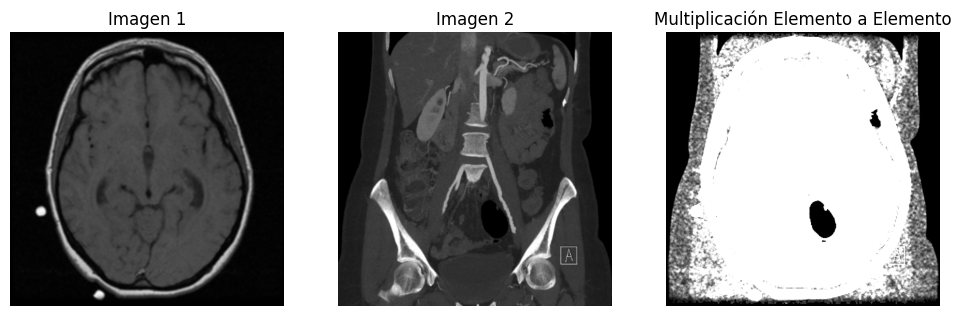

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title("Imagen 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title("Imagen 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_multiplicada, cmap='gray')
plt.title("Multiplicación Elemento a Elemento")
plt.axis("off")

plt.show()


Desde el punto de vista biomédico, esta operación puede ser útil en la fusión de imágenes provenientes de diferentes modalidades, como resonancia magnética y tomografía, permitiendo resaltar zonas de interés compartidas. Asimismo, puede emplearse para enfatizar estructuras específicas, mejorar la detección de patrones y apoyar en el análisis de tejidos o anomalías, facilitando la interpretación y el diagnóstico en estudios clínicos.


## **PARTE II. OPERACIONES LÓGICAS**

***Instrucciones:*** Realiza las operaciones lógicas a las imágenes médicas.

### **EJERCICIO 1.** ***Ecualización.***

Para la realización de esta fase de la actividad utilizaremos la imagen de una Resonancia Magnética cerebral con bajo contraste.

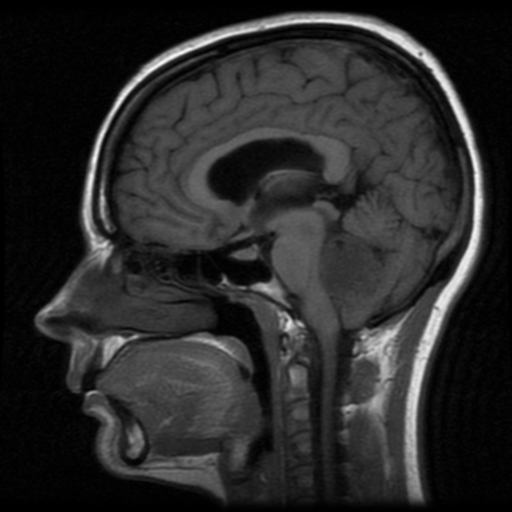

Utilizaremos diversas librerías que nos permitirán realizar nuestras operaciones, pero la principal es OpenCV. OpenCV es una librería que permite procesar imágenes y extraer características usando Python.

También, utilizaremos Matplotlib, esta se emplea para graficar y visualizar la imagen de gráficos en un panel de visualización.

In [ ]:
import cv2
import matplotlib.pyplot as plt

Cargaremos la imagen médica con el comando ***cv2.imread***, y para el preprocesamiento de la imagen, leeremos la imagen en escala de grises reduciendo la información a un canal de intensidad facilitandonos la interpretación del histograma. Se realizará mediante el comando ***cv2.IMREAD_GRAYSCALE***.


In [ ]:
imagenRM = cv2.imread("RMcerebral.jpg", cv2.IMREAD_GRAYSCALE)

Ahora, obtendremos el histograma de la imagen, para ambas definimos los parámetros claves de la función para una imagen en escala de grises y a 8 bits.  

Se calcula el histograma de la imagen con la función ***cv2.calcHist()***, la cual permite obtener la distribución de los niveles de intensidad de la imagen. Trabajamos sin máscara, con 256 bins y en un rango de intensidades de 0 a 256

In [ ]:
histograma = cv2.calcHist([imagenRM], [0], None, [256], [0,256])

Luego se aplica la ecualización de histograma con ***cv2.equalizeHist()*** la cual toma la imagen en escala de grises como entrada y genera una nueva imagen en la que los niveles de intensidad están más distribuidos, permitiendo así resaltar detalles que no eran visibles en la imagen original.

In [ ]:
ecualizado = cv2.equalizeHist(imagenRM)

Una vez obtenida la imagen ecualizada, se calcula su histograma utilizando nuevamente la función ***cv2.calcHist()***, lo que permite comparar la distribución de intensidades antes y después de la ecualización.

In [ ]:
histecualizado = cv2.calcHist([ecualizado], [0], None, [256], [0,256])

Mediante el código realizado se obtiene lo siguiente:


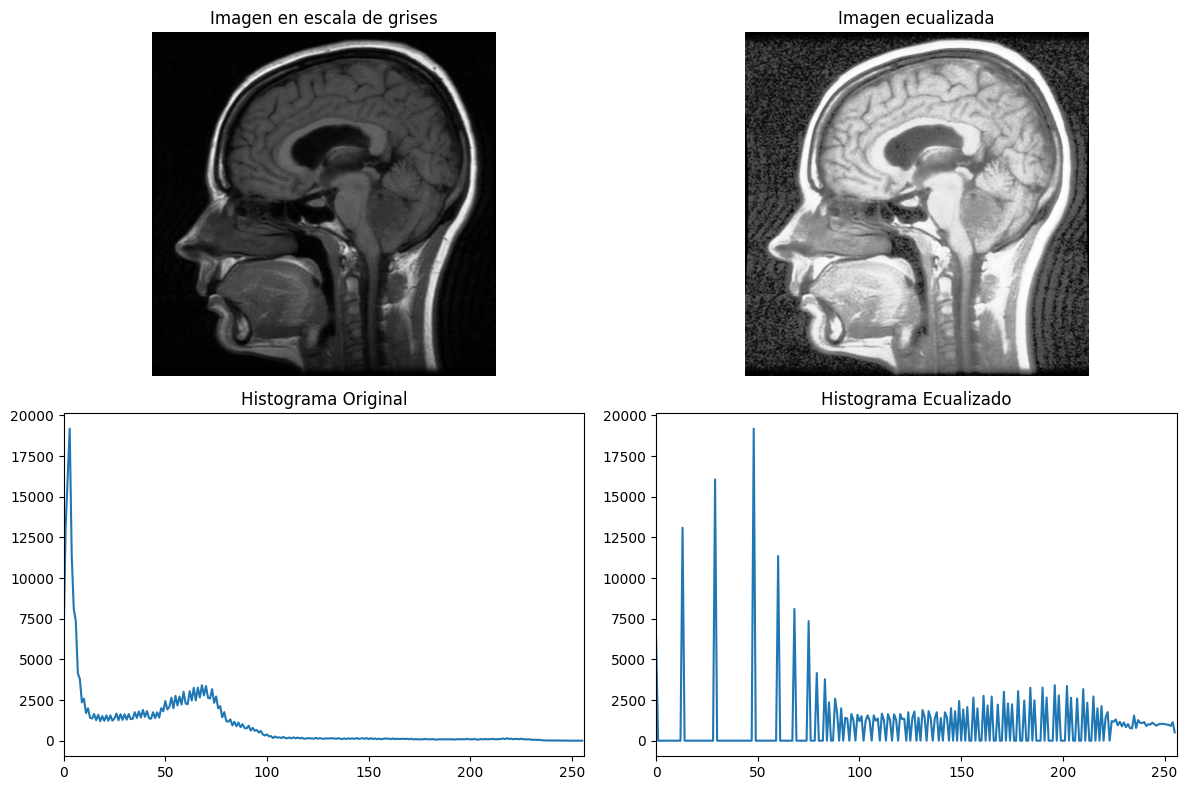

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(imagenRM, cmap='gray')
plt.title("Imagen en escala de grises")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(ecualizado, cmap='gray')
plt.title("Imagen ecualizada")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(histograma)
plt.title("Histograma Original")
plt.xlim([0,256])

plt.subplot(2,2,4)
plt.plot(histecualizado)
plt.title("Histograma Ecualizado")
plt.xlim([0,256])

plt.tight_layout()
plt.show()